# Progressive GAN — High-Resolution Generation via Growing

This notebook implements **Progressive GAN** (Karras et al., 2017), following Module 17.

Every GAN so far in this series has trained at one fixed resolution. Progressive GAN attacks a different problem: how do you train a Generator for **high-resolution** images without making optimization dramatically harder?

The answer: **don't start at the target resolution.**

Train at `4x4` first, then grow to `8x8`, then `16x16`, then `32x32`. Each new resolution's layers are added via a **fade-in** that blends the old (upscaled) output with the new output, weighted by a parameter `alpha` that ramps from `0` to `1`. By the time `alpha = 1`, the new layers are fully in charge and the old pathway can be retired.

Two consequences fall out:

1. The model learns coarse structure first (low frequencies), then detail (high frequencies). This is *curriculum learning* applied to GANs.
2. Adding new layers doesn't catastrophically destabilize the trained model, because the old path is still doing most of the work during the transition.

We pre-build the full Generator and Discriminator with one block per resolution, then drive both networks from a single `(level, alpha)` schedule.

## Implementation Plan

- **Resolution schedule**: `4 -> 8 -> 16 -> 32`. Four stages, three fade-in transitions. Maximum resolution `32x32` — large enough to see the progressive effect, small enough that MNIST training finishes in reasonable time on CPU.
- **Generator**: a `4x4` initial block, then three upsampling blocks (`4->8`, `8->16`, `16->32`). Each block has two conv layers with `BatchNorm` + `LeakyReLU`, preceded by a `2x` nearest-neighbor upsample. A `to_rgb` `1x1` conv sits at the output of every level, and the **current output** is the upscaled old `to_rgb` blended with the new `to_rgb` weighted by `alpha`.
- **Discriminator**: mirror of the Generator. A `from_rgb` `1x1` conv at every level, three downsampling blocks, and a final `4x4 -> 1` linear head. Discriminator blocks use `LeakyReLU` only — **no normalization** in D, which is the PGAN convention.
- **Resolution schedule** (epochs are 1-indexed in the printout):
  - Epochs 1-2: train at level 0 (`4x4`)
  - Epochs 3-5: fade-in to level 1 (`8x8`), `alpha` ramps `0 -> 1`
  - Epochs 6-8: train at level 1 (`8x8`)
  - Epochs 9-11: fade-in to level 2 (`16x16`)
  - Epochs 12-14: train at level 2 (`16x16`)
  - Epochs 15-17: fade-in to level 3 (`32x32`)
  - Epochs 18-25: train at level 3 (`32x32`)
- **Loss**: standard `BCEWithLogitsLoss` — the innovation here is in the architecture and training schedule, not the loss function.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

The schedule is encoded as a list of `(start_epoch, end_epoch, level, target_alpha)` tuples. A target alpha of `0.0` means *fade-in*: alpha ramps linearly across those epochs. A target of `1.0` means *stabilize at full resolution*.

In [2]:
latent_dim    = 100
img_channels  = 1
max_res       = 32                # 4 -> 8 -> 16 -> 32
batch_size    = 32
lr            = 2e-4
betas         = (0.5, 0.999)
epochs        = 25

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('samples_PGAN', exist_ok=True)

# Resolution schedule: (start_epoch_inclusive, end_epoch_exclusive, level, target_alpha)
# During a fade-in segment (target_alpha=0.0) alpha ramps from 0 to 1 across the segment.
schedule = [
    (0,  2,  0, 1.0),   # train at 4x4
    (2,  5,  1, 0.0),   # fade-in to 8x8
    (5,  8,  1, 1.0),   # train at 8x8
    (8,  11, 2, 0.0),   # fade-in to 16x16
    (11, 14, 2, 1.0),   # train at 16x16
    (14, 17, 3, 0.0),   # fade-in to 32x32
    (17, 25, 3, 1.0),   # train at 32x32
]

def level_and_alpha(epoch):
    """Return (level, alpha) for the given epoch index (0-based)."""
    for start, end, level, target in schedule:
        if start <= epoch < end:
            if target == 0.0:
                progress = (epoch - start) / max(1, (end - start))
                return level, float(progress)
            return level, target
    return 3, 1.0   # default: highest resolution, full alpha

Using device: cuda


## 2. Data — MNIST Resized to the Current Resolution

We resize MNIST once to the **maximum** resolution (`32x32`) at load time. Inside the training loop, we further downsample to whatever resolution the current `(level, alpha)` pair requires.

In [3]:
transform = transforms.Compose([
    transforms.Resize(max_res),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

## 3. Weight Initialization

Same DCGAN-style init. Note that we DO initialize weights in *every* block at construction time — even blocks for resolutions we haven't reached yet. They sit idle until their level becomes active.

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

## 4. The Generator — Pre-Built, Activated by `(level, alpha)`

Spatial flow:

```
z -> Linear -> 4x4 (256 ch)            [level 0 base]
    -> block_8  -> 8x8  (128 ch)
    -> block_16 -> 16x16 (64 ch)
    -> block_32 -> 32x32 (32 ch)
```

Each `to_rgb` is a `1x1` conv that projects features to image space at that resolution. The **forward pass** walks up to the current `level`, and at the topmost active level it blends the upscaled old `to_rgb` with the new `to_rgb` by `alpha`.

The fade-in equation:

```
out = (1 - alpha) * upsample(prev_rgb) + alpha * new_rgb
```

In [5]:
class ProgressiveGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.latent_dim = latent_dim

        # Level 0: 4x4 base. z -> Linear -> 4x4 conv -> features
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.conv_4 = nn.Sequential(
            nn.Conv2d(256, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.to_rgb_4 = nn.Conv2d(256, img_channels, 1)

        # Level 1: 8x8. Upsample + 2 convs + to_rgb
        self.block_8 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.to_rgb_8 = nn.Conv2d(128, img_channels, 1)

        # Level 2: 16x16
        self.block_16 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.to_rgb_16 = nn.Conv2d(64, img_channels, 1)

        # Level 3: 32x32
        self.block_32 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.to_rgb_32 = nn.Conv2d(32, img_channels, 1)

    def forward(self, z, level=3, alpha=1.0):
        # Initial projection: z -> 4x4 features (256 ch)
        x = self.fc(z).view(z.size(0), 256, 4, 4)
        x = self.conv_4(x)

        if level == 0:
            return self.to_rgb_4(x)

        blocks   = [self.block_8,  self.block_16, self.block_32]
        to_rgbs  = [self.to_rgb_8, self.to_rgb_16, self.to_rgb_32]

        prev_rgb = self.to_rgb_4(x)
        for i in range(level):
            x = blocks[i](x)
            cur_rgb = to_rgbs[i](x)

            if i == level - 1 and alpha < 1.0:
                upscaled = F.interpolate(prev_rgb, scale_factor=2, mode='nearest')
                prev_rgb = (1 - alpha) * upscaled + alpha * cur_rgb
            else:
                prev_rgb = cur_rgb

        return prev_rgb

## 5. The Discriminator — Mirror Image

Spatial flow (for input at the current resolution):

```
input resolution (4, 8, 16, or 32)
  -> from_rgb (1x1 conv)
  -> block(s) with strided convs / AvgPool to downsample
  -> 4x4 features (256 ch)
  -> final linear -> 1 logit
```

Two PGAN conventions in the Discriminator:

- **No normalization** in the D blocks. We use `LeakyReLU` activations only.
- **`from_rgb` per level**, because the same `1x1` conv can't reasonably convert `1 -> 32` channels AND `1 -> 256` channels at the same time. Each level has its own `from_rgb`.

In [6]:
class ProgressiveDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # from_rgb: one per level
        self.from_rgb_32 = nn.Conv2d(img_channels, 32,  1)
        self.from_rgb_16 = nn.Conv2d(img_channels, 64,  1)
        self.from_rgb_8  = nn.Conv2d(img_channels, 128, 1)
        self.from_rgb_4  = nn.Conv2d(img_channels, 256, 1)

        # Down-blocks: each takes input at one resolution and outputs the next-lower
        self.block_32_to_16 = nn.Sequential(
            nn.Conv2d(32, 32, 3, 1, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 3, 1, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2),
        )
        self.block_16_to_8 = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, 1, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2),
        )
        self.block_8_to_4 = nn.Sequential(
            nn.Conv2d(128, 128, 3, 1, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 1, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.AvgPool2d(2),
        )

        # Final head: 4x4 features -> 1 logit
        self.final = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
        )

    def forward(self, x, level=3, alpha=1.0):
        if level == 0:
            return self.final(self.from_rgb_4(x))

        if level == 3:
            # Full path: 32x32 -> 16 -> 8 -> 4 -> logit
            x = self.from_rgb_32(x)
            x = self.block_32_to_16(x)
            x = self.block_16_to_8(x)
            x = self.block_8_to_4(x)
            return self.final(x)

        if level == 2:
            # 16x16 input. New path: from_rgb_16 -> block_16_to_8 -> block_8_to_4
            x_new = self.block_8_to_4(self.block_16_to_8(self.from_rgb_16(x)))
            if alpha < 1.0:
                # Old path: downsample 16x16 -> 8x8, from_rgb_8 -> block_8_to_4
                x_old = self.block_8_to_4(self.from_rgb_8(F.avg_pool2d(x, 2)))
                x = (1 - alpha) * x_old + alpha * x_new
            else:
                x = x_new
            return self.final(x)

        if level == 1:
            # 8x8 input. New path: from_rgb_8 -> block_8_to_4
            x_new = self.block_8_to_4(self.from_rgb_8(x))
            if alpha < 1.0:
                # Old path: downsample 8x8 -> 4x4, from_rgb_4 (no block)
                x_old = self.from_rgb_4(F.avg_pool2d(x, 2))
                x = (1 - alpha) * x_old + alpha * x_new
            else:
                x = x_new
            return self.final(x)

## 6. Models, Optimizers, Loss

Standard `BCEWithLogitsLoss`, Adam with the same LR / betas as DCGAN.

In [7]:
G = ProgressiveGenerator(latent_dim=latent_dim).to(device)
D = ProgressiveDiscriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

bce = nn.BCEWithLogitsLoss()

print(f'G params: {sum(p.numel() for p in G.parameters()):,}')
print(f'D params: {sum(p.numel() for p in D.parameters()):,}')

G params: 1,586,020
D params: 1,630,657


## 7. Fixed Noise for Visualization

Same noise every epoch. At low resolution the grid will look pixelated; at high resolution it sharpens up.

In [8]:
fixed_noise = torch.randn(64, latent_dim, device=device)

## 8. The Training Loop

Each iteration:

1. Compute `(level, alpha)` from the current epoch via the schedule.
2. Downsample the real MNIST batch from `32x32` to the current target resolution.
3. **Phase A — D**: real at target resolution -> `1`, fake (detached) -> `0`. BCE sum.
4. **Phase B — G**: fake at target resolution -> target `1`. BCE.

Same `torch.no_grad()` discipline as every other notebook — the gradient bookkeeping gets a bit more interesting because the network *architecture* changes during training, but the optimizer calls are the same.

In [9]:
losses_g = []
losses_d = []
level_history = []
alpha_history = []

data_iter = iter(dataloader)

G.train(); D.train()

for epoch in range(epochs):
    level, alpha = level_and_alpha(epoch)
    target_res = 4 * (2 ** level)
    level_history.append(level)
    alpha_history.append(alpha)

    sum_d = 0.0
    sum_g = 0.0
    n_batches = 0

    for real_max, _ in dataloader:
        real_max = real_max.to(device)
        b = real_max.size(0)

        # Downsample real images to current resolution
        real = F.interpolate(real_max, size=(target_res, target_res), mode='bilinear')

        valid = torch.ones (b, 1, device=device)
        fake_t = torch.zeros(b, 1, device=device)

        # -----------------
        # Phase A: Train D
        # -----------------
        optimizer_D.zero_grad()

        # Real
        real_logits = D(real, level, alpha)
        d_real_loss = bce(real_logits, valid)

        # Fake
        z = torch.randn(b, latent_dim, device=device)
        with torch.no_grad():
            gen_imgs = G(z, level, alpha)
        fake_logits = D(gen_imgs, level, alpha)
        d_fake_loss = bce(fake_logits, fake_t)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Phase B: Train G
        # -----------------
        optimizer_G.zero_grad()

        gen_imgs = G(z, level, alpha)            # NO detach
        validity_logits = D(gen_imgs, level, alpha)
        g_loss = bce(validity_logits, valid)
        g_loss.backward()
        optimizer_G.step()

        sum_d += d_loss.item()
        sum_g += g_loss.item()
        n_batches += 1

    avg_d = sum_d / n_batches
    avg_g = sum_g / n_batches
    losses_d.append(avg_d)
    losses_g.append(avg_g)

    print(
        f"Epoch [{epoch+1:2d}/{epochs}]  "
        f"level={level}  res={target_res:2d}x{target_res:2d}  alpha={alpha:.2f}  "
        f"D: {avg_d:.3f}  G: {avg_g:.3f}"
    )

    # Sample grid at the *final* resolution so the visualization is consistent
    G.eval()
    with torch.no_grad():
        sample_imgs = G(fixed_noise, level=3, alpha=1.0).detach().cpu()
    save_image(
        sample_imgs,
        f"samples_PGAN/epoch_{epoch+1:02d}.png",
        nrow=8,
        normalize=True,
    )
    G.train()

print('Training done.')

Epoch [ 1/25]  level=0  res= 4x 4  alpha=1.00  D: 0.697  G: 0.700
Epoch [ 2/25]  level=0  res= 4x 4  alpha=1.00  D: 0.695  G: 0.697
Epoch [ 3/25]  level=1  res= 8x 8  alpha=0.00  D: 0.695  G: 0.697
Epoch [ 4/25]  level=1  res= 8x 8  alpha=0.33  D: 0.696  G: 0.699
Epoch [ 5/25]  level=1  res= 8x 8  alpha=0.67  D: 0.693  G: 0.697
Epoch [ 6/25]  level=1  res= 8x 8  alpha=1.00  D: 0.689  G: 0.727
Epoch [ 7/25]  level=1  res= 8x 8  alpha=1.00  D: 0.466  G: 1.662
Epoch [ 8/25]  level=1  res= 8x 8  alpha=1.00  D: 0.423  G: 2.013
Epoch [ 9/25]  level=2  res=16x16  alpha=0.00  D: 0.474  G: 1.792
Epoch [10/25]  level=2  res=16x16  alpha=0.33  D: 0.495  G: 1.693
Epoch [11/25]  level=2  res=16x16  alpha=0.67  D: 0.499  G: 1.490
Epoch [12/25]  level=2  res=16x16  alpha=1.00  D: 0.742  G: 0.866
Epoch [13/25]  level=2  res=16x16  alpha=1.00  D: 0.678  G: 0.776
Epoch [14/25]  level=2  res=16x16  alpha=1.00  D: 0.635  G: 0.976
Epoch [15/25]  level=3  res=32x32  alpha=0.00  D: 0.466  G: 2.388
Epoch [16/

## 9. Final Samples at the Highest Resolution

The Generator was sampled at `level=3, alpha=1.0` every epoch so the saved grids are all `32x32`. The earlier ones reflect what a partially-trained Generator can produce when forced to its maximum resolution — early epochs' grids tend to look coarse and smoothed, because the higher-resolution blocks haven't been trained yet.

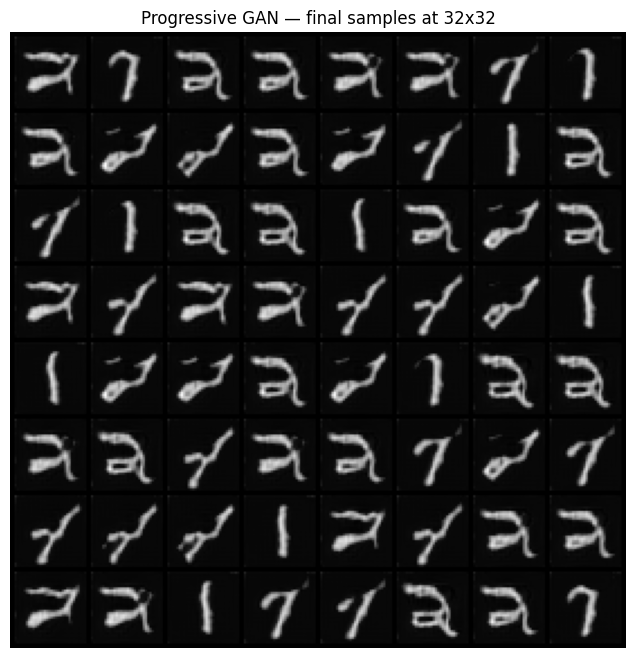

In [10]:
G.eval()
with torch.no_grad():
    samples = G(fixed_noise, level=3, alpha=1.0).cpu()

grid = make_grid(samples, nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Progressive GAN — final samples at 32x32')
plt.show()

## 10. Training Progression and the Resolution Schedule

Below: each saved epoch grid stacked left-to-right, plus the (level, alpha) schedule plotted over time. The schedule plot makes the curriculum visible — three plateaus at `alpha=1`, separated by three diagonal ramps where the new resolution fades in.

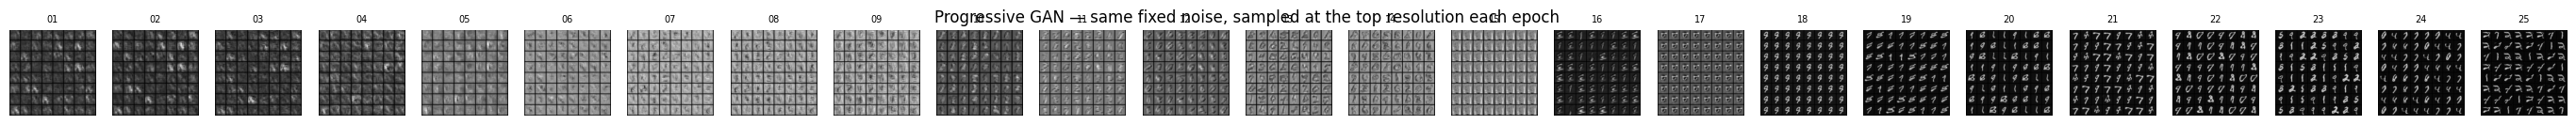

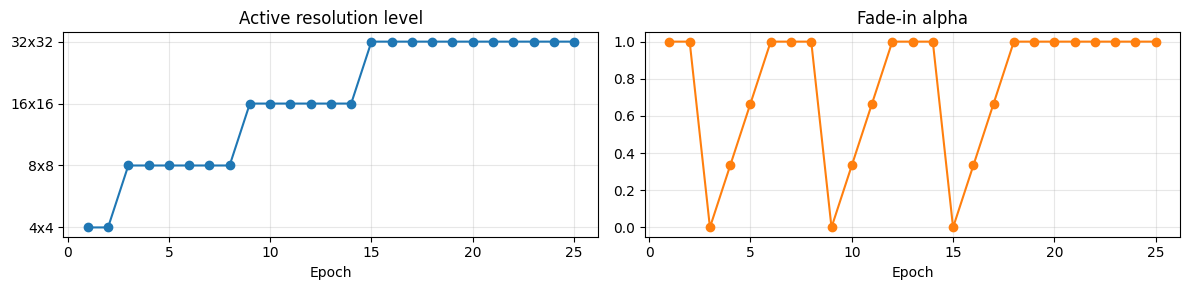

In [11]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples_PGAN/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(1.4 * len(paths), 1.4))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0], fontsize=7)
        ax.axis('off')
    plt.suptitle('Progressive GAN — same fixed noise, sampled at the top resolution each epoch')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(range(1, epochs + 1), level_history, marker='o')
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(['4x4', '8x8', '16x16', '32x32'])
axes[0].set_xlabel('Epoch')
axes[0].set_title('Active resolution level')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs + 1), alpha_history, marker='o', color='tab:orange')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Fade-in alpha')
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Loss Curves

Loss curves will show discontinuities at the schedule boundaries — that's expected and *informative*. When the resolution jumps up at the start of a fade-in phase, the Discriminator suddenly sees a new input distribution, so its loss spikes briefly. As `alpha` ramps up and the new blocks train, things settle back to the standard adversarial equilibrium.

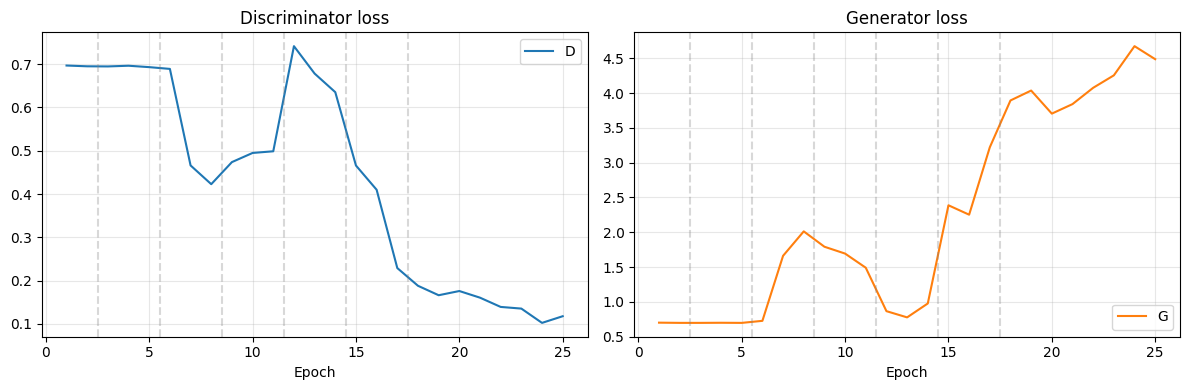

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, epochs + 1), losses_d, label='D', color='tab:blue')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Discriminator loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs + 1), losses_g, label='G', color='tab:orange')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Generator loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Mark schedule boundaries
for ax in axes:
    for start, _, _, _ in schedule[1:]:
        ax.axvline(start + 0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Recap — How Progressive GAN Differs From Earlier Architectures

| Concern | DCGAN / WGAN / cGAN / Pix2Pix / CycleGAN | Progressive GAN |
|---|---|---|
| Output resolution | fixed at construction | **grows during training** |
| Number of layers | fixed | **grows during training** |
| Adding new layers | never | **scheduled fade-in** with `alpha` in `[0, 1]` |
| Generator norm | BatchNorm | BatchNorm (per block) |
| Discriminator norm | varies (often none) | **no normalization** |
| Loss | BCE / Wasserstein / hybrid | **BCE** (the innovation is the schedule) |
| Curriculum | none | **resolution curriculum** |
| to_rgb / from_rgb | single output conv | **one per level** |

**What changed and why.**

- **Resolution as part of the curriculum.** Each new resolution is a new, easier sub-problem to warm up on. By the time the model is asked to produce `32x32`, it has already learned how to produce plausible `4x4` and `8x8` outputs — the higher-resolution blocks only have to *refine*, not invent from scratch.
- **Fade-in prevents abrupt shifts.** Adding a freshly-initialized upsampling block to an already-trained Generator is a discontinuity in the optimization landscape. Blending the upscaled old output with the new output by `alpha` makes the transition continuous. By the time `alpha=1`, the new blocks have had a full epoch or more to specialize.
- **`to_rgb` and `from_rgb` per level.** A single output conv cannot reasonably convert `1 -> 32` channels AND `1 -> 256` channels at the same time. Each level needs its own projection to/from image space, so the right one can be selected based on the current resolution.
- **No normalization in the Discriminator.** The PGAN authors found that BatchNorm in D destabilizes training. We use just `LeakyReLU` activations.
- **Architecture is pre-built, activation is conditional.** We don't literally add layers at runtime. Every block exists from epoch 0; the `(level, alpha)` pair drives which blocks are active. This is a cleaner implementation than dynamically inserting layers, and it makes the schedule trivially reproducible.

**Common implementation pitfalls** — quick reference:

- **`alpha` is per-resolution-pair.** During a fade-in segment, `alpha` ramps `0 -> 1` over a few epochs. Outside fade-in segments, `alpha=1`. Forgetting to ramp it is the single most common bug in re-implementations.
- **Resize real images to the current resolution.** The dataset is loaded once at the maximum resolution (`32x32` here). Inside the loop, `F.interpolate` down to the current target. Otherwise you're feeding mismatched shapes to G and D.
- **Don't put BatchNorm in the Discriminator.** Even though the Generator has BatchNorm and it works fine there. The asymmetry is intentional and matters.
- **Pass `(level, alpha)` to both G and D in every forward.** They need to agree on the resolution and the fade-in weight. Forgetting to pass `alpha` to D while passing it to G is a classic mismatch.
- **Loss discontinuities at schedule boundaries are normal.** Don't panic when D's loss spikes at the start of a fade-in phase. It's the Discriminator seeing a new input distribution. It will recover.
- **Save visualizations at the *final* resolution.** Sampling at the current resolution produces grids of different sizes across epochs, which makes montage comparisons awkward. Sampling at `level=3, alpha=1.0` every epoch gives you consistent `32x32` grids that you can compare side-by-side.

**Next in the series** (Module 18): StyleGAN. Progressive GAN solves the *resolution* problem — how to train high-resolution GANs. StyleGAN solves a different problem: how to give the user fine-grained *control* over the generated image. It introduces a mapping network (`z -> w`), an intermediate latent space that disentangles style attributes, and AdaIN-based style injection at every Generator layer. That's the bridge from "generate realistic images" to "generate realistic images I can control."

In [13]:
import zipfile
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = 'samples_PGAN'
zip_file_name = f'{directory_to_zip}.zip'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(directory_to_zip):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

print(f"'{directory_to_zip}' has been successfully zipped into '{zip_file_name}'")

# Offer the zip file for download
files.download(zip_file_name)

'samples_PGAN' has been successfully zipped into 'samples_PGAN.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>